In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00a 0:00:01


In [ ]:
import os
import yaml
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

DATA_PATH = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"

train_images = DATA_PATH + "/train/images"
train_labels = DATA_PATH + "/train/labels"

val_images   = DATA_PATH + "/val/images"
val_labels   = DATA_PATH + "/val/labels"

print("train_images:", train_images)
print("train_labels:", train_labels)

train_images: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images
train_labels: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels


In [ ]:
def clean_data(images_path, labels_path):
    images = os.listdir(images_path)
    removed = 0

    for img in images:
        label = img.replace(".jpg",".txt").replace(".png",".txt")
        label_path = os.path.join(labels_path, label)

        if not os.path.exists(label_path):

            removed += 1

    print(f"Found {removed} images without labels ")

In [ ]:
clean_data(train_images, train_labels)
clean_data(val_images, val_labels)

Found 0 images without labels 
Found 0 images without labels 


In [ ]:
import yaml

data_yaml = {
    "path": DATA_PATH,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": ["smoke", "fire"],
    "nc": 2
}


with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created ")

data.yaml created 


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

In [ ]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    augment=True
)


Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79eaea3dddc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from IPython.display import FileLink

FileLink('/kaggle/working/runs/detect/train/weights/best.pt')

/kaggle/working/runs/detect/train/weights/best.pt

In [ ]:
model.val()

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 299.7±122.5 MB/s, size: 164.8 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels... 3094 images, 1375 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 617.4it/s 5.0s0.0s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg'
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg'
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/WEB07539.jpg: ignoring corrupt image/label: [Errno 30] Rea

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e936211760>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
model.val(
    data="/kaggle/working/data.yaml",
    split="test"
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.2±0.2 ms, read: 18.6±11.1 MB/s, size: 211.6 KB)
val: Scanning /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels... 4295 images, 2005 backgrounds, 15 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 184.8it/s 23.3s<0.1s
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0297]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0156]
val: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB11243.jpg'
val: /kaggle/input/

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79eaebeeed80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Selected Image: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB09580.jpg

image 1/1 /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/WEB09580.jpg: 384x640 (no detections), 25.0ms
Speed: 1.4ms preprocess, 25.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/runs/detect/predict


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

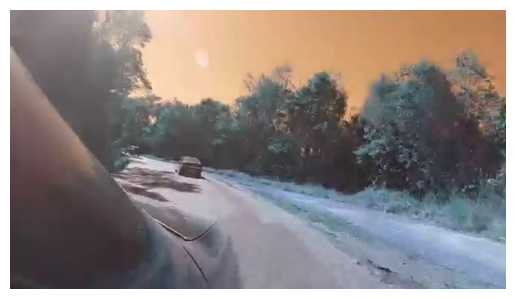

In [ ]:
import os
import random

test_path = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images"

images = os.listdir(test_path)
random_img = random.choice(images)
img_path = os.path.join(test_path, random_img)

print("Selected Image:", img_path)

results = model.predict(
    source=img_path,
    conf=0.25,
    save=True
)

img = results[0].plot()

from matplotlib import pyplot as plt
plt.imshow(img)
plt.axis("off")

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))

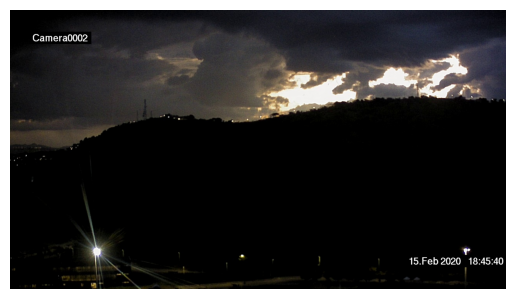

In [ ]:
import matplotlib.pyplot as plt
import cv2


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
model.predict(
    source="/kaggle/input/datasets/hosamelbosily/test-fire/images (8).jpg",
    save=True,
    conf=0.25
)


image 1/1 /kaggle/input/datasets/hosamelbosily/test-fire/images (8).jpg: 448x640 1 smoke, 52.0ms
Speed: 3.6ms preprocess, 52.0ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'fire', 1: 'smoke'}
 obb: None
 orig_img: array([[[27, 42, 61],
         [27, 42, 61],
         [28, 43, 62],
         ...,
         [ 7, 10, 15],
         [ 7, 10, 15],
         [ 7, 10, 15]],
 
        [[29, 43, 65],
         [27, 44, 63],
         [29, 43, 65],
         ...,
         [ 7, 10, 15],
         [ 7, 10, 15],
         [ 7, 10, 15]],
 
        [[30, 46, 69],
         [28, 47, 68],
         [30, 46, 69],
         ...,
         [ 7, 10, 15],
         [ 7, 10, 15],
         [ 7, 10, 15]],
 
        ...,
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1],
         ...,
         [ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1]],
 
        [[ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1],
         ...,
         [ 1,  1,  1],
         [ 1,  1,  1],
         [ 1,  1,  1]],
 
        [[ 1,  1,

In [ ]:
results = model.predict(source=img)

print(results[0].boxes)


image 1/1 /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/AoF07627.jpg: 384x640 (no detections), 11.5ms
Speed: 2.4ms preprocess, 11.5ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([], device='cuda:0')
conf: tensor([], device='cuda:0')
data: tensor([], device='cuda:0', size=(0, 6))
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([0, 6])
xywh: tensor([], device='cuda:0', size=(0, 4))
xywhn: tensor([], device='cuda:0', size=(0, 4))
xyxy: tensor([], device='cuda:0', size=(0, 4))
xyxyn: tensor([], device='cuda:0', size=(0, 4))


In [ ]:
model = YOLO("/kaggle/input/models/hosamelbosily/best/tensorflow2/default/1/yolov8s.pt")

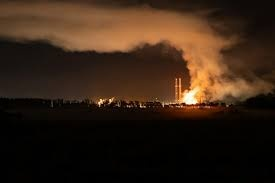

In [ ]:
import glob
from IPython.display import Image, display

imgs = glob.glob("/kaggle/working/runs/detect/predict/*.jpg")

display(Image(filename=imgs[0]))